In [2]:
#Import pandas, matplotlib.pyplot, and seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Read in the csv file and print the head to see the columns and data examples
df = pd.read_csv('C:/Users/vsofi/Desktop/Springboard/sleep_mobile_stress_dataset_15000.csv')
print(df.head().T)

                                         0        1         2  \
user_id                                  1        2         3   
age                                     56       46        32   
gender                              Female   Female    Female   
occupation                        Designer  Teacher  Designer   
daily_screen_time_hours               3.26     1.85      3.04   
phone_usage_before_sleep_minutes        86       32       107   
sleep_duration_hours                  5.31     7.36       4.5   
sleep_quality_score                   7.72      9.7      6.38   
stress_level                          3.49     3.01      5.03   
caffeine_intake_cups                     0        0         0   
physical_activity_minutes               35       16        17   
notifications_received_per_day         119      299        21   
mental_fatigue_score                  3.57     1.91      6.05   

                                                  3        4  
user_id                   

In [7]:
#Check out the summary of the data
df.info()
#Looks like all the numerical variables are either floats or integers!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [6]:
#Check for missing values
missing_count = df.isnull().sum()
print(missing_count)
#Looks like there is no missing data

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64


In [13]:
# Returns True if every combination is unique, False otherwise
is_unique = not df.duplicated().any()

print(f"Are all combinations unique? {is_unique}")

Are all combinations unique? True


In [12]:
# Finding the duplicates. Let's look closer to see if the duplicates are really duplicates
duplicates = df.duplicated(subset=['age', 'gender', 'occupation'], keep = False)
print(df[duplicates].sort_values(by = ['age','gender', 'occupation']))

#Looks like there are combinations with the same age, gender, and occupation, but that is to be expected in a 
#dataset with 15000 entries. The actual numerical data for these "similial users" seem to be very different.

       user_id  age  gender         occupation  daily_screen_time_hours  \
610        611   18  Female           Designer                     1.11   
667        668   18  Female           Designer                     8.09   
771        772   18  Female           Designer                     7.70   
1051      1052   18  Female           Designer                     9.09   
2334      2335   18  Female           Designer                     9.95   
...        ...  ...     ...                ...                      ...   
14137    14138   59   Other         Researcher                     1.90   
147        148   59   Other  Software Engineer                     6.08   
11624    11625   59   Other  Software Engineer                     3.88   
553        554   59   Other            Teacher                     2.25   
10598    10599   59   Other            Teacher                     8.59   

       phone_usage_before_sleep_minutes  sleep_duration_hours  \
610                               

In [14]:
#Some summary statistics of the data to try to see if there is much data that is out of range, etc.
df.describe()
#Everything looks good: age is between 18 and 59, screen time is 10 h max, sleep duration is 4-9 h, caffeine intake is 0-4 cups...
#All the variables seem to fall into a very reasonable range

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [16]:
#Curiously there are "Other" genders. Let's look as the make up of the data in terms of gender
df['gender'].value_counts()
#Seems reasonable: ~3.9% "Other" is to be expected

gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64

In [17]:
#Let's look as the make up of the data in terms of occupation to see if there any insights to be gained
df['occupation'].value_counts()
#The data set definitely looks synthetic. lol

occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64

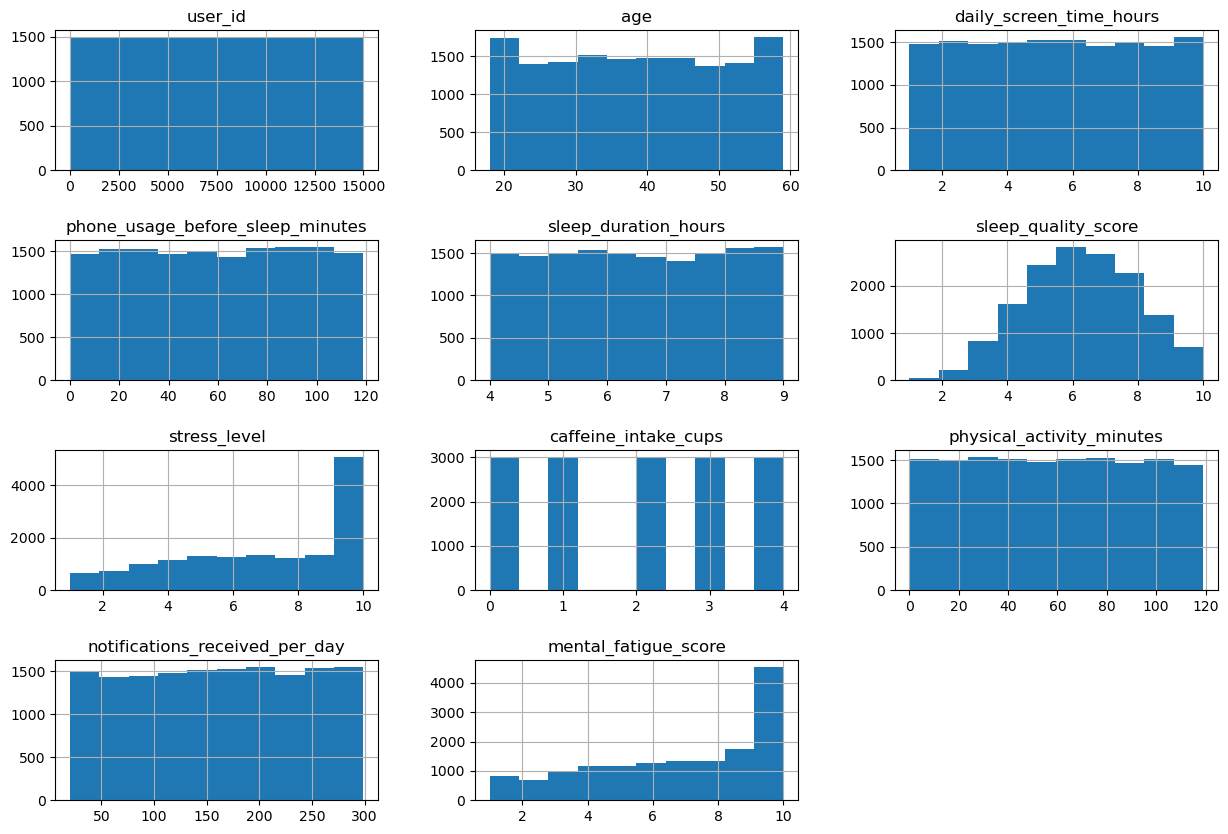

In [18]:
#Let's get some of this data plotted to see how it looks
df.hist(figsize=(15,10))
plt.subplots_adjust(hspace=0.5);

#nothing particularly ineresting other than a dispoportionate number of people have 
#a very high stress level and mental fatigue score

In [ ]:
#The df is ready to go! There are no missing or out of bounds values. 
#The numerical values are all either integers or floats.
#There is a good spread of data between male, female, and other, as well as between 8 occupations.
#None of the data is duplicated